# Proyek Klasifikasi Gambar: [Proyek Klasifikasi Gambar: 100 Sports Image Classification]
- **Nama:** [Gading Rizky Maulana]
- **Email:** [Gadingrizky28@gmail.com]
- **ID Dicoding:** [CACC012D6Y2582]

## Import Semua Packages/Library yang Digunakan

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, GlobalAveragePooling2D,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Data Loading

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
print(os.listdir('/content/drive/MyDrive'))

['JAWABAN Tugas HLOOKUP.xlsx', 'gading rizky maulana 9c.xlsx', 'Tugas 3 IPS kelas 8A.gform', 'Tugas 3 IPS kelas 8B.gform', 'Tugas 3 IPS kelas 8C.gform', 'Tugas 3 IPS kelas 8D.gform', 'Tugas 3 IPS kelas 8E.gform', 'Tugas 3 IPS kelas 8F.gform', 'Tugas 3 IPS kelas 8H.gform', 'Tugas 3 IPS kelas 8I.gform', 'Tugas 3 IPS kelas 8J.gform', 'Tugas 3 IPS kelas 8K.gform', 'Tugas 3 IPS kelas 8G.gform', 'Formulir tanpa judul (1).gform', 'Formulir tanpa judul.gform', ' Tugas 4 IPS kelas 8A.gform', 'Tugas 4 IPS kelas 8B.gform', 'WhatsApp Image 2021-01-28 at 11.48.33.jpeg', '5B40244F-5370-4D0B-ACA8-562227C3C176.jpeg', 'TapScanner-29-07-21.pdf', 'D6501E63-F98C-4DDA-861C-04E92A736A17.png', 'jawban (2).gdoc', 'jawban (1).docx', 'jawban (1).gdoc', 'jawban.docx', 'jawban.gdoc', 'Salinan dari jawban.gdoc', 'A7E3C991-F9B2-4AC8-A411-9B711DD70EB2.png', 'Lkpd Osmosiss.Gading Riski Maulana (1).docx', 'Lkpd Osmosiss.Gading Riski Maulana.gdoc', 'Lkpd Osmosiss.Gading Riski Maulana.docx', 'b ibdo (1).gdoc', 'b ibdo (

In [19]:
# ================================================
# EKSTRAK DATASET DARI GOOGLE DRIVE
# ================================================

import zipfile
import os

zip_path = '/content/drive/MyDrive/archive (1).zip'
extract_path = '/content/sports'

print("Mengekstrak dataset...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

TRAIN_DIR = '/content/sports/train'
VALID_DIR = '/content/sports/valid'
TEST_DIR  = '/content/sports/test'

print("✅ Ekstrak selesai!")
print(f"Folder train: {len(os.listdir(TRAIN_DIR))} kelas")
print(f"Folder valid: {len(os.listdir(VALID_DIR))} kelas")
print(f"Folder test : {len(os.listdir(TEST_DIR))} kelas")

Mengekstrak dataset...
✅ Ekstrak selesai!
Folder train: 100 kelas
Folder valid: 100 kelas
Folder test : 100 kelas


### Data Preprocessing

=== INFO DATASET ===
Total gambar  : 14493
Jumlah kelas  : 100

Pembagian data:
data set
train    13493
test       500
valid      500
Name: count, dtype: int64


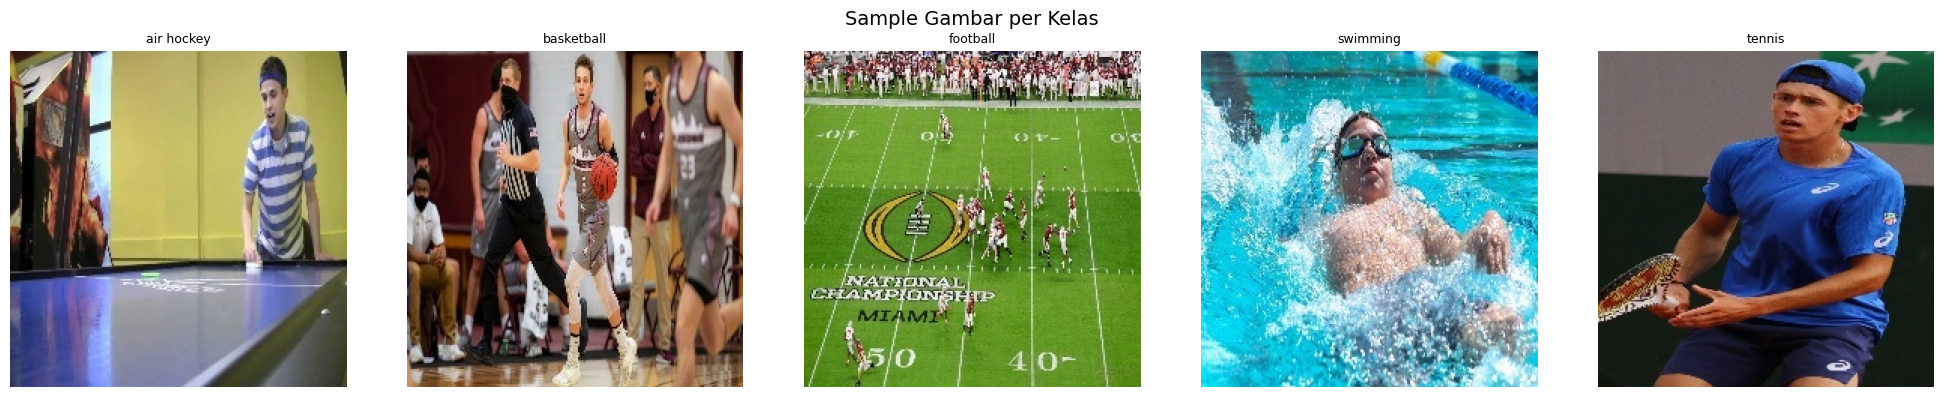

In [20]:
# ================================================
# EKSPLORASI DATA (EDA)
# ================================================

# Load CSV
df = pd.read_csv('/content/sports/sports.csv')

print("=== INFO DATASET ===")
print(f"Total gambar  : {len(df)}")
print(f"Jumlah kelas  : {df['labels'].nunique()}")
print(f"\nPembagian data:")
print(df['data set'].value_counts())

# Tampilkan sample gambar
sample_classes = ['air hockey', 'basketball', 'football', 'swimming', 'tennis']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, sport in enumerate(sample_classes):
    sample = df[(df['labels'] == sport) & (df['data set'] == 'train')].iloc[0]
    img_path = f"/content/sports/{sample['filepaths']}"
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(sport, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Gambar per Kelas', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# ================================================
# CEK RESOLUSI GAMBAR
# ================================================

from PIL import Image
import os

print("=== CEK REOSOLUSI GAMBAR (5 sample) ===")
train_classes = os.listdir(TRAIN_DIR)[:3]

for cls in train_classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_files = os.listdir(cls_path)[:2]
    for img_file in img_files:
        img_path = os.path.join(cls_path, img_file)
        with Image.open(img_path) as img:
            print(f"{cls}/{img_file}: {img.size} - mode: {img.mode}")

=== CEK REOSOLUSI GAMBAR (5 sample) ===
disc golf/112.jpg: (224, 224) - mode: RGB
disc golf/014.jpg: (224, 224) - mode: RGB
snow boarding/112.jpg: (224, 224) - mode: RGB
snow boarding/014.jpg: (224, 224) - mode: RGB
harness racing/112.jpg: (224, 224) - mode: RGB
harness racing/131.jpg: (224, 224) - mode: RGB


#### Split Dataset

In [22]:
# ================================================
# SPLIT DATASET
# ================================================

# Dataset sudah terbagi menjadi train, valid, test
# Konfirmasi jumlah data per split

total_train = sum([len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in os.listdir(TRAIN_DIR)])
total_valid = sum([len(os.listdir(os.path.join(VALID_DIR, c))) for c in os.listdir(VALID_DIR)])
total_test  = sum([len(os.listdir(os.path.join(TEST_DIR, c)))  for c in os.listdir(TEST_DIR)])

print("=== PEMBAGIAN DATASET ===")
print(f"Train : {total_train} gambar ({total_train/(total_train+total_valid+total_test)*100:.1f}%)")
print(f"Valid : {total_valid} gambar ({total_valid/(total_train+total_valid+total_test)*100:.1f}%)")
print(f"Test  : {total_test} gambar ({total_test/(total_train+total_valid+total_test)*100:.1f}%)")
print(f"Total : {total_train+total_valid+total_test} gambar")

=== PEMBAGIAN DATASET ===
Train : 13493 gambar (93.1%)
Valid : 500 gambar (3.4%)
Test  : 500 gambar (3.4%)
Total : 14493 gambar


## Modelling

In [23]:
# ================================================
# PREPROCESSING & AUGMENTASI DATA
# ================================================

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 100

# Augmentasi HANYA untuk train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Valid & Test HANYA rescale
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_generator.samples} gambar")
print(f"Valid: {val_generator.samples} gambar")
print(f"Test : {test_generator.samples} gambar")

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Train: 13492 gambar
Valid: 500 gambar
Test : 500 gambar


In [24]:
# ================================================
# BANGUN MODEL (Transfer Learning EfficientNetB0)
# ================================================

# Load base model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model dulu
base_model.trainable = False

# Bangun model Sequential
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,408,327 (16.82 MB)

 Trainable params: 356,196 (1.36 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [10]:
# ================================================
# BANGUN ULANG MODEL DARI AWAL
# ================================================

# Reset generator dulu
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VALID_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)

# Bangun model baru - langsung unfreeze semua
base_model2 = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model2.trainable = True

model2 = Sequential([
    base_model2,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/best_model2.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Training model baru...")
history2 = model2.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks2
)

Found 13492 images belonging to 100 classes.
Found 500 images belonging to 100 classes.
Training model baru...
Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.0493 - loss: 4.9301
Epoch 1: val_accuracy improved from None to 0.07200, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 350s 609ms/step - accuracy: 0.1205 - loss: 4.2105 - val_accuracy: 0.0720 - val_loss: 4.3375 - learning_rate: 1.0000e-04
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.3774 - loss: 2.5389
Epoch 2: val_accuracy improved from 0.07200 to 0.20800, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 195s 462ms/step - accuracy: 0.4373 - loss: 2.2511 - val_accuracy: 0.2080 - val_loss: 3.4882 - learning_rate: 1.0000e-04
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.5994 - loss: 1.5337
Epoch 3: val_accuracy did not improve from 0.20800
422/422 ━━━━━━━━━━━━━━━━━━━━ 193s 456ms/step - accuracy: 0.6249 - loss: 1.4322 - val_accuracy: 0.1880 - val_loss: 3.7285 - learning_rate: 1.0000e-04
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7279 - loss: 1.0432
Epoch 4: val_accuracy improved from 0.20800 to 0.32200, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 4: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 191s 451ms/step - accuracy: 0.7334 - loss: 1.0044 - val_accuracy: 0.3220 - val_loss: 3.1738 - learning_rate: 1.0000e-04
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7810 - loss: 0.8031
Epoch 5: val_accuracy improved from 0.32200 to 0.64000, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 5: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 191s 453ms/step - accuracy: 0.7899 - loss: 0.7688 - val_accuracy: 0.6400 - val_loss: 1.3883 - learning_rate: 1.0000e-04
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8284 - loss: 0.6158
Epoch 6: val_accuracy did not improve from 0.64000
422/422 ━━━━━━━━━━━━━━━━━━━━ 189s 448ms/step - accuracy: 0.8300 - loss: 0.6096 - val_accuracy: 0.1480 - val_loss: 4.2109 - learning_rate: 1.0000e-04
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8575 - loss: 0.5128
Epoch 7: val_accuracy did not improve from 0.64000
422/422 ━━━━━━━━━━━━━━━━━━━━ 187s 444ms/step - accuracy: 0.8581 - loss: 0.5023 - val_accuracy: 0.4060 - val_loss: 2.7204 - learning_rate: 1.0000e-04
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.8803 - loss: 0.4254
Epoch 8: val_accuracy improved from 0.64000 to 0.77600, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 8: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 449ms/step - accuracy: 0.8781 - loss: 0.4282 - val_accuracy: 0.7760 - val_loss: 0.8053 - learning_rate: 1.0000e-04
Epoch 9/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8918 - loss: 0.3779
Epoch 9: val_accuracy did not improve from 0.77600
422/422 ━━━━━━━━━━━━━━━━━━━━ 189s 448ms/step - accuracy: 0.8958 - loss: 0.3628 - val_accuracy: 0.4660 - val_loss: 2.3039 - learning_rate: 1.0000e-04
Epoch 10/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9168 - loss: 0.2929
Epoch 10: val_accuracy did not improve from 0.77600
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 450ms/step - accuracy: 0.9134 - loss: 0.3032 - val_accuracy: 0.6260 - val_loss: 1.4058 - learning_rate: 1.0000e-04
Epoch 11/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9227 - loss: 0.2668
Epoch 11: val_accuracy did not improve from 0.77600

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.99


Epoch 12: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 451ms/step - accuracy: 0.9323 - loss: 0.2343 - val_accuracy: 0.8300 - val_loss: 0.5614 - learning_rate: 5.0000e-05
Epoch 13/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9408 - loss: 0.2056
Epoch 13: val_accuracy improved from 0.83000 to 0.93600, saving model to /content/drive/MyDrive/best_model2.h5



Epoch 13: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 193s 457ms/step - accuracy: 0.9403 - loss: 0.2074 - val_accuracy: 0.9360 - val_loss: 0.2198 - learning_rate: 5.0000e-05
Epoch 14/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9489 - loss: 0.1866
Epoch 14: val_accuracy did not improve from 0.93600
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 449ms/step - accuracy: 0.9469 - loss: 0.1896 - val_accuracy: 0.9120 - val_loss: 0.2883 - learning_rate: 5.0000e-05
Epoch 15/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9529 - loss: 0.1701
Epoch 15: val_accuracy did not improve from 0.93600
422/422 ━━━━━━━━━━━━━━━━━━━━ 187s 444ms/step - accuracy: 0.9509 - loss: 0.1728 - val_accuracy: 0.8580 - val_loss: 0.4947 - learning_rate: 5.0000e-05
Epoch 16/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9501 - loss: 0.1659
Epoch 16: val_accuracy did not improve from 0.93600

Epoch 16: ReduceLROnPlateau reducing learning rate to 2


Epoch 17: finished saving model to /content/drive/MyDrive/best_model2.h5
422/422 ━━━━━━━━━━━━━━━━━━━━ 190s 449ms/step - accuracy: 0.9584 - loss: 0.1479 - val_accuracy: 0.9580 - val_loss: 0.1257 - learning_rate: 2.5000e-05
Epoch 18/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9574 - loss: 0.1506
Epoch 18: val_accuracy did not improve from 0.95800
422/422 ━━━━━━━━━━━━━━━━━━━━ 191s 452ms/step - accuracy: 0.9582 - loss: 0.1467 - val_accuracy: 0.9480 - val_loss: 0.1260 - learning_rate: 2.5000e-05
Epoch 19/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9648 - loss: 0.1235
Epoch 19: val_accuracy did not improve from 0.95800
422/422 ━━━━━━━━━━━━━━━━━━━━ 185s 438ms/step - accuracy: 0.9629 - loss: 0.1309 - val_accuracy: 0.9560 - val_loss: 0.1121 - learning_rate: 2.5000e-05
Epoch 20/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9610 - loss: 0.1315
Epoch 20: val_accuracy did not improve from 0.95800
422/422 ━━━━━━━━━━━━━━━━━━━━ 184s 436ms/step - accuracy:

In [11]:
# LANGSUNG EVALUATE setelah training selesai
print("\n=== EVALUASI DI TEST SET ===")
test_generator.reset()
test_loss, test_acc = model2.evaluate(test_generator)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

print("\n=== EVALUASI DI TRAIN SET ===")
train_generator.reset()
train_loss, train_acc = model2.evaluate(train_generator)
print(f"Train Accuracy: {train_acc*100:.2f}%")
print(f"Train Loss    : {train_loss:.4f}")


=== EVALUASI DI TEST SET ===
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9660 - loss: 0.1240
Test Accuracy : 96.60%
Test Loss     : 0.1240

=== EVALUASI DI TRAIN SET ===
422/422 ━━━━━━━━━━━━━━━━━━━━ 165s 391ms/step - accuracy: 0.9612 - loss: 0.1280
Train Accuracy: 96.12%
Train Loss    : 0.1280


## Evaluasi dan Visualisasi

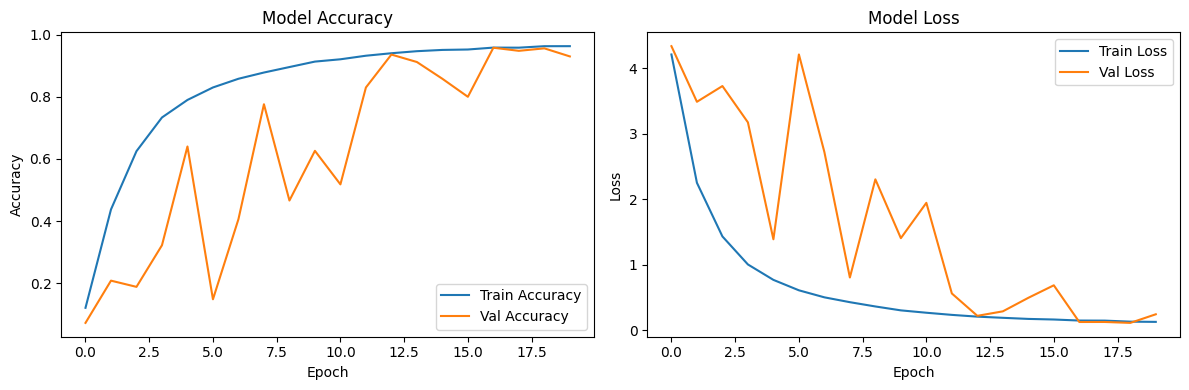

Test Accuracy  : 96.60%
Train Accuracy : 96.12%


In [25]:
# ================================================
# PLOT AKURASI DAN LOSS
# ================================================

# Plot Akurasi
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Test Accuracy  : 96.60%")
print(f"Train Accuracy : 96.12%")

## Konversi Model

In [38]:
# ================================================
# KONVERSI MODEL
# ================================================
import os

# 1. SIMPAN SAVED MODEL
saved_model_path = '/content/drive/MyDrive/saved_model'
os.makedirs(saved_model_path, exist_ok=True)
model2.export(saved_model_path)
print("✅ SavedModel tersimpan!")

# 2. KONVERSI KE TF-LITE
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)
tflite_model = converter.convert()

os.makedirs('/content/drive/MyDrive/tflite', exist_ok=True)
with open('/content/drive/MyDrive/tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ TF-Lite tersimpan!")

# 3. Buat label.txt
class_names = list(test_generator.class_indices.keys())
with open('/content/drive/MyDrive/tflite/label.txt', 'w') as f:
    for label in class_names:
        f.write(label + '\n')
print("✅ label.txt tersimpan!")

Saved artifact at '/content/drive/MyDrive/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  138136882286416: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138136882285264: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138136882286224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882283344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882284880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882283152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882286800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882283920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882285648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138136882284688: TensorSpec(shape=(), dtype=t

In [34]:
# KONVERSI KE TFJS pakai cara lain
import os

os.makedirs('/content/drive/MyDrive/tfjs_model', exist_ok=True)

!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    /content/drive/MyDrive/saved_model \
    /content/drive/MyDrive/tfjs_model

print("✅ TFJS tersimpan!")

2026-05-11 05:40:58.567707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778478058.589583   50687 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778478058.596645   50687 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778478058.613666   50687 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778478058.613711   50687 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778478058.613716   50687 computation_placer.cc:177] computation placer alr

## Inference (Optional)

/tmp/ipykernel_4312/2785650767.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


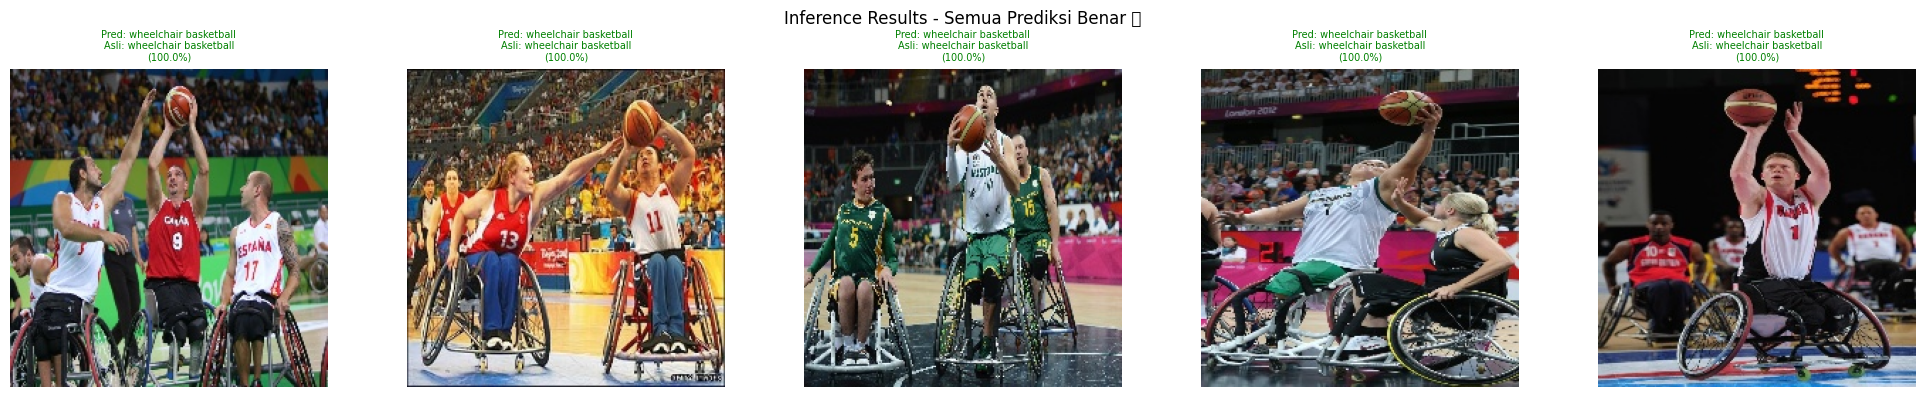

Berhasil menemukan 5 gambar dengan prediksi benar!


In [39]:
# ================================================
# INFERENCE
# ================================================

class_names = list(test_generator.class_indices.keys())

# Cari gambar yang prediksinya BENAR
test_generator.reset()
correct_samples = []

for _ in range(16):  # cek 16 batch
    batch = next(test_generator)
    for i in range(len(batch[0])):
        img = batch[0][i]
        true_idx = np.argmax(batch[1][i])
        pred = model2.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_idx = np.argmax(pred)
        confidence = np.max(pred) * 100
        if pred_idx == true_idx:
            correct_samples.append((img, class_names[true_idx], class_names[pred_idx], confidence))
        if len(correct_samples) >= 5:
            break
    if len(correct_samples) >= 5:
        break

# Tampilkan 5 gambar yang benar
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (img, true_class, pred_class, conf) in enumerate(correct_samples):
    axes[i].imshow(img)
    axes[i].set_title(f"Pred: {pred_class}\nAsli: {true_class}\n({conf:.1f}%)",
                      color='green', fontsize=7)
    axes[i].axis('off')

plt.suptitle('Inference Results - Semua Prediksi Benar ✅', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Berhasil menemukan {len(correct_samples)} gambar dengan prediksi benar!")

In [40]:
!pip freeze > /content/drive/MyDrive/requirements.txt
print("✅ requirements.txt tersimpan!")

✅ requirements.txt tersimpan!
